# TorchBragg in 20 minutes: simulate, then refine

This notebook walks through the PyTorch port of nanoBragg (`nanobrag_torch`) with the
smallest possible setup, then uses automatic differentiation to recover two
parameters (detector distance and unit-cell edge) from a simulated image.

Everything runs on the CPU in a couple of minutes. Set `device = "cuda"` below to use a GPU.

**What nanoBragg computes.** For every pixel it sums, over all sub-samples (sub-pixels,
sources, spindle steps, mosaic domains), the intensity of a perfect nanocrystal:

$I_\text{pixel} \propto r_e^2 \cdot \text{fluence} \cdot \Omega \cdot P \cdot \big|F_\text{cell}(h,k,l)\,F_\text{latt}(h,k,l)\big|^2$

where $F_\text{latt}$ is the finite-lattice shape transform (a product of `sin(Nπh)/sin(πh)` terms for an
`N×N×N` unit-cell crystal), $\Omega$ the pixel solid angle and $P$ the polarization factor. Because every step
is a tensor operation, `loss.backward()` gives exact gradients with respect to any input.

In [1]:
import os, time
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"        # avoid MKL/OpenMP clashes on some machines
os.environ["NANOBRAGG_DISABLE_COMPILE"] = "1"      # eager mode: no torch.compile warm-up; flip to "0" for speed on repeated calls

import numpy as np
import torch
import matplotlib.pyplot as plt

from nanobrag_torch.config import CrystalConfig, DetectorConfig, BeamConfig, DetectorConvention
from nanobrag_torch.models.crystal import Crystal
from nanobrag_torch.models.detector import Detector
from nanobrag_torch.simulator import Simulator

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float64        # float64 for refinement; float32 is fine for forward-only work
torch.manual_seed(0)
print("torch", torch.__version__, "| device:", device)

torch 2.6.0 | device: cpu


## 1. Describe the experiment

Three small config objects hold everything the simulator needs. Units are the nanoBragg CLI units:
Å and degrees for the cell, mm for the detector, Å for the wavelength.

In [2]:
crystal_cfg = CrystalConfig(
    cell_a=100.0, cell_b=100.0, cell_c=100.0,          # Å
    cell_alpha=90.0, cell_beta=90.0, cell_gamma=90.0,  # degrees
    N_cells=(5, 5, 5),                                  # crystal is 5 unit cells along each axis
    default_F=100.0,                                    # every reflection gets |F| = 100 (no HKL file needed)
    misset_deg=(10.0, 20.0, 30.0),                      # crystal orientation: rotations about x, y, z
)

detector_cfg = DetectorConfig(
    distance_mm=100.0,
    pixel_size_mm=0.1,
    spixels=256, fpixels=256,                           # a single 256x256 panel
    detector_convention=DetectorConvention.MOSFLM,     # beam centre in the middle, MOSFLM axis convention
    oversample=1,                                       # sub-pixel sampling (1 = pixel centres only)
)

beam_cfg = BeamConfig(wavelength_A=1.0)

crystal = Crystal(crystal_cfg, device=device, dtype=dtype)
detector = Detector(detector_cfg, device=device, dtype=dtype)
sim = Simulator(crystal, detector, beam_config=beam_cfg, device=device, dtype=dtype)

## 2. Simulate one image

`Simulator.run()` returns the image as a `(slow, fast)` tensor in photons per pixel (before noise).

(256, 256) image in 0.01 s; max 151.3 photons/pixel


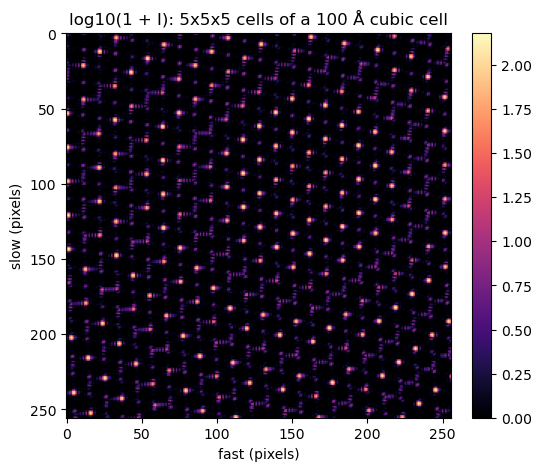

In [3]:
t0 = time.perf_counter()
image = sim.run()
print(f"{tuple(image.shape)} image in {time.perf_counter() - t0:.2f} s; max {image.max():.1f} photons/pixel")

def show(img, title="", ax=None, vmax=None):
    ax = ax or plt.gca()
    im = ax.imshow(np.log10(1 + img.detach().cpu().numpy()), cmap="magma", vmax=vmax)
    ax.set_title(title); ax.set_xlabel("fast (pixels)"); ax.set_ylabel("slow (pixels)")
    return im

plt.figure(figsize=(5.5, 5))
im = show(image, "log10(1 + I): 5x5x5 cells of a 100 Å cubic cell")
plt.colorbar(im, fraction=0.046); plt.show()

The concentric fringes around each Bragg spot are the shape transform of the 5-cell crystal; a larger
`N_cells` sharpens the spots. Try changing `misset_deg`, `N_cells` or `wavelength_A` and re-running the two
cells above.

## 3. Write it out, if you need files

The same float image nanoBragg's C program writes with `-floatfile` is one line away, and the
CLI (`python -m nanobrag_torch ...`) accepts the C flags.

In [4]:
image.detach().cpu().numpy().astype(np.float32).tofile("tutorial_float.bin")   # raw float32, C-compatible
print("wrote tutorial_float.bin,", os.path.getsize("tutorial_float.bin") // 1024, "kB")

wrote tutorial_float.bin, 256 kB


## 4. Refinement: recover distance and cell edge from an image

We now pretend `image` is an experimental frame whose detector distance and cell edge we do not know.
We start from wrong guesses, make them `torch` tensors with `requires_grad=True`, and let Adam walk
them back to the truth by minimising a least-squares loss on `log(1 + I)` (the log keeps weak pixels
from being ignored).

Two things make this work:

* every parameter that should be refined is passed to the configs **as a tensor**, not a float;
* the model is rebuilt inside the loop so the forward pass sees the current parameter values.

In [5]:
target = image.detach()

true_distance, true_cell = 100.0, 100.0
distance_mm = torch.tensor(103.0, device=device, dtype=dtype, requires_grad=True)   # 3 mm off
cell_a      = torch.tensor(97.0,  device=device, dtype=dtype, requires_grad=True)   # 3 Å off

def forward(distance_mm, cell_a):
    ccfg = CrystalConfig(cell_a=cell_a, cell_b=cell_a, cell_c=cell_a,           # keep the cell cubic
                         cell_alpha=90.0, cell_beta=90.0, cell_gamma=90.0,
                         N_cells=(5, 5, 5), default_F=100.0, misset_deg=(10.0, 20.0, 30.0))
    dcfg = DetectorConfig(distance_mm=distance_mm, pixel_size_mm=0.1, spixels=256, fpixels=256,
                          detector_convention=DetectorConvention.MOSFLM, oversample=1)
    s = Simulator(Crystal(ccfg, device=device, dtype=dtype), Detector(dcfg, device=device, dtype=dtype),
                  beam_config=beam_cfg, device=device, dtype=dtype)
    return s.run()

def loss_fn(pred, target):
    return torch.mean((torch.log1p(pred) - torch.log1p(target)) ** 2)

optimizer = torch.optim.Adam([distance_mm, cell_a], lr=0.3)
history = {"loss": [], "distance": [], "cell_a": []}

t0 = time.perf_counter()
for it in range(60):
    optimizer.zero_grad()
    pred = forward(distance_mm, cell_a)
    loss = loss_fn(pred, target)
    loss.backward()
    optimizer.step()
    history["loss"].append(loss.item()); history["distance"].append(distance_mm.item()); history["cell_a"].append(cell_a.item())
    if it % 10 == 0 or it == 59:
        print(f"iter {it:3d}  loss {loss.item():.3e}  distance {distance_mm.item():7.3f} mm  cell_a {cell_a.item():7.3f} Å")
print(f"{time.perf_counter() - t0:.1f} s")

iter   0  loss 8.013e-01  distance 102.700 mm  cell_a  97.300 Å


iter  10  loss 1.053e-02  distance  99.806 mm  cell_a 100.223 Å


iter  20  loss 9.763e-02  distance 100.288 mm  cell_a  99.792 Å


iter  30  loss 5.622e-03  distance 100.071 mm  cell_a 100.035 Å


iter  40  loss 1.449e-02  distance  99.982 mm  cell_a 100.136 Å


iter  50  loss 1.458e-03  distance 100.016 mm  cell_a 100.107 Å


iter  59  loss 9.085e-04  distance 100.066 mm  cell_a 100.058 Å
1.3 s


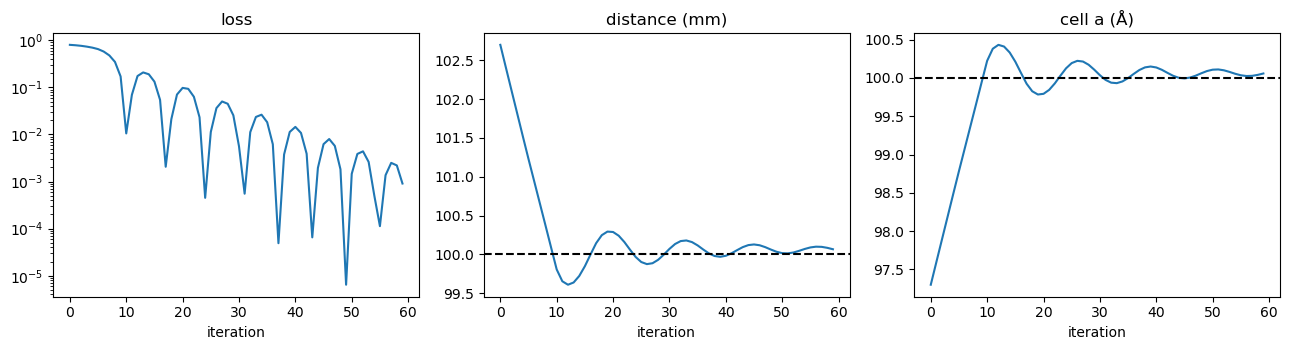

recovered distance = 100.066 mm (true 100.0),  cell a = 100.058 Å (true 100.0)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].semilogy(history["loss"]); axes[0].set_title("loss"); axes[0].set_xlabel("iteration")
axes[1].plot(history["distance"]); axes[1].axhline(true_distance, ls="--", c="k"); axes[1].set_title("distance (mm)")
axes[2].plot(history["cell_a"]);   axes[2].axhline(true_cell, ls="--", c="k");     axes[2].set_title("cell a (Å)")
for ax in axes[1:]: ax.set_xlabel("iteration")
plt.tight_layout(); plt.show()

print(f"recovered distance = {distance_mm.item():.3f} mm (true {true_distance}),  cell a = {cell_a.item():.3f} Å (true {true_cell})")

## 5. Check the gradients are right

`torch.autograd.gradcheck` compares the analytic gradient with finite differences. It needs float64 and
is slow on big images, so we use a 32x32 detector here.

In [7]:
from torch.autograd import gradcheck

def small_image_sum(cell_a):
    ccfg = CrystalConfig(cell_a=cell_a, cell_b=100.0, cell_c=100.0, N_cells=(3, 3, 3), default_F=100.0)
    dcfg = DetectorConfig(distance_mm=100.0, pixel_size_mm=0.4, spixels=32, fpixels=32, oversample=1)
    s = Simulator(Crystal(ccfg, dtype=torch.float64), Detector(dcfg, dtype=torch.float64),
                  beam_config=BeamConfig(wavelength_A=1.0), dtype=torch.float64)
    return s.run().sum()

x = torch.tensor(100.0, dtype=torch.float64, requires_grad=True)
print("gradcheck passed:", gradcheck(small_image_sum, (x,), eps=1e-6, atol=1e-4, rtol=1e-3))

gradcheck passed: True


## 6. Where to go next

* **More parameters.** Any config field that accepts a tensor can be refined the same way: `misset_deg`,
  `detector_rotx_deg`, `wavelength_A`, `mosaic_spread_deg`, `fluence`, the structure-factor grid itself.
* **Real geometry.** `nanobrag_torch.compat.cctbx` builds the same objects from dxtbx `Detector` /
  `Beam` / `Crystal` models and cctbx miller arrays (`simulator_from_dxtbx`, `MultiPanelSimulator`).
* **Speed.** Remove `NANOBRAGG_DISABLE_COMPILE` to let `torch.compile` fuse the kernel (one-off warm-up
  per detector shape), and keep the `Simulator` alive across iterations instead of rebuilding it.
* **Reference C code.** `python -m nanobrag_torch` accepts the nanoBragg C flags, so any simulation here
  can be checked against the C binary with the same command line.